# Pima Indians Diabetes

El dataset Pima Indians Diabetes es un conjunto de datos muy conocido en machine learning y estadística médica que se usa para tareas de clasificación binaria, especialmente para entrenar y evaluar modelos que predicen si una persona tiene o no diabetes tipo 2.

##### 📄 Origen
- Proviene de un estudio del National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) de EE.UU.
- Se recopiló en una población específica: mujeres mayores de 21 años de la tribu Pima, que viven en Arizona, debido a la alta incidencia de diabetes en esta comunidad.


# 📊 Data Envelopment Analysis (DEA)

## 📦 1. Instalación de librerías *necesarias*

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Visualizar valores faltantes (NaN) en un dataset.
import missingno as msno

## 📚 2. Carga de librerías y del dataset

In [3]:
# Cargar el dataset desde un archivo CSV (cambia la ruta al archivo si es necesario)
data = pd.read_csv('PimaIndiansDiabetes2.csv')

# Verificar las primeras filas
data.head()

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,pos
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,neg
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,pos
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,neg
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,pos


## 🔍 3. Exploración inicial del dataset (head y tipos de datos)

In [3]:

# Eliminar las columnas 'insulin' y 'triceps'
data_cleaned = data.drop(columns=['insulin', 'triceps'])

# Eliminar filas con valores faltantes
data_cleaned = data_cleaned.dropna()

# Ver las dimensiones del nuevo dataset
print(f"Dimensiones de data_cleaned: {data_cleaned.shape}")

# Ver la estructura del nuevo dataset
print(f"Estructura de data_cleaned:")
print(data_cleaned.info())

Dimensiones de data_cleaned: (724, 7)
Estructura de data_cleaned:
<class 'pandas.core.frame.DataFrame'>
Index: 724 entries, 0 to 767
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pregnant  724 non-null    int64  
 1   glucose   724 non-null    float64
 2   pressure  724 non-null    float64
 3   mass      724 non-null    float64
 4   pedigree  724 non-null    float64
 5   age       724 non-null    int64  
 6   diabetes  724 non-null    object 
dtypes: float64(4), int64(2), object(1)
memory usage: 45.2+ KB
None


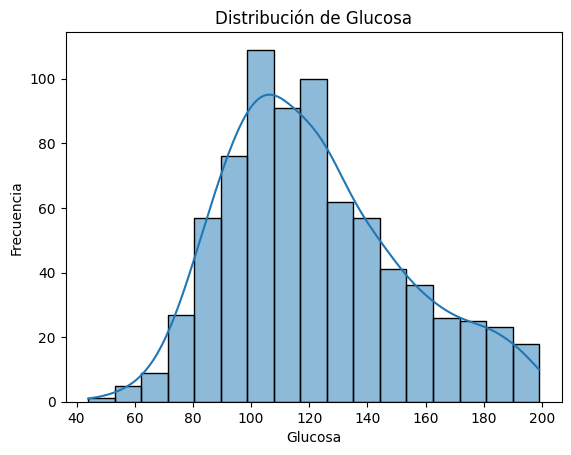

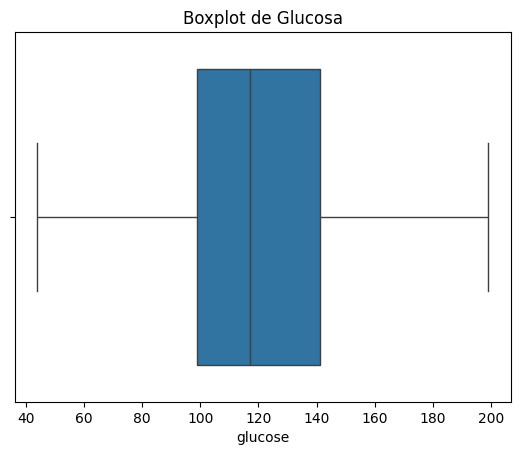

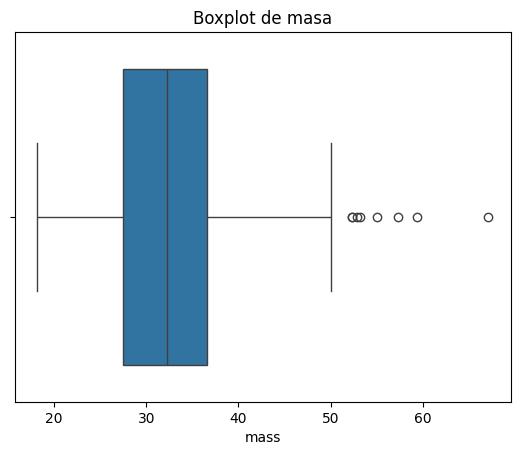

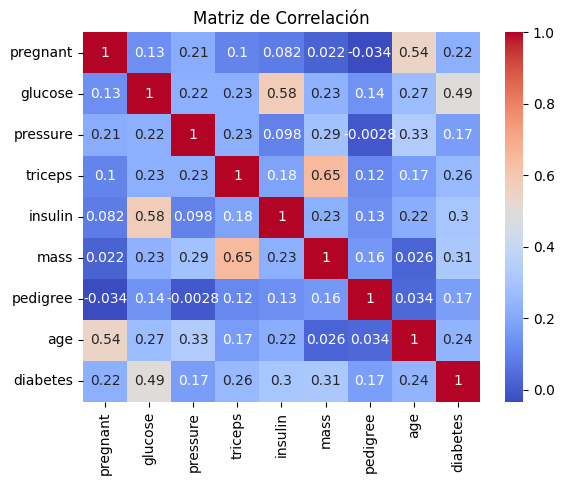

In [4]:

# Visualizar la distribución de una variable (glucosa en el ejemplo de R)
sns.histplot(data['glucose'], kde=True)
plt.title("Distribución de Glucosa")
plt.xlabel("Glucosa")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot para detectar valores atípicos
sns.boxplot(x=data['glucose'])
plt.title("Boxplot de Glucosa")
plt.show()

# Boxplot para detectar valores atípicos
sns.boxplot(x=data['mass'])
plt.title("Boxplot de masa")
plt.show()

# Convertir la columna 'diabetes' de texto ('pos', 'neg') a valores numéricos (1, 0)
data['diabetes'] = data['diabetes'].map({'pos': 1, 'neg': 0})

# Identificación de correlaciones
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación")
plt.show()

# Análisis de Componentes Principales (PCA)

Proporción de varianza explicada por cada componente:  [0.32692996 0.21372169 0.15851579 0.1276584  0.10534367 0.06783049]


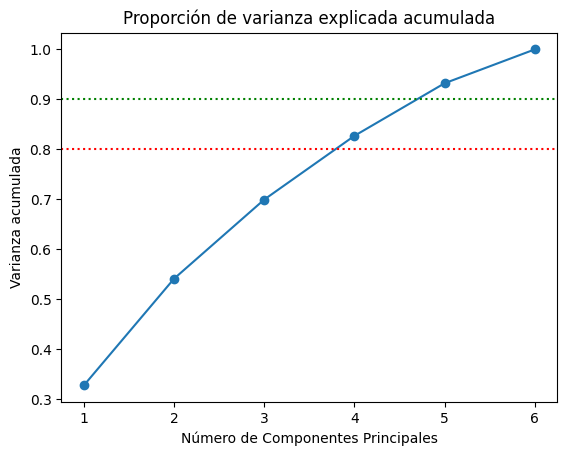

In [5]:

# Ahora aplicar PCA sobre los datos limpios
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Normalizar los datos antes de PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_cleaned.drop('diabetes', axis=1))

# Aplicar PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Proporción de varianza explicada por cada componente
pve = pca.explained_variance_ratio_
print("Proporción de varianza explicada por cada componente: ", pve)

# Visualizar el gráfico de varianza acumulada
plt.plot(range(1, len(pve)+1), np.cumsum(pve), marker='o')
plt.axhline(y=0.80, color='red', linestyle=':', label='80% Varianza Explicada')
plt.axhline(y=0.90, color='green', linestyle=':', label='90% Varianza Explicada')
plt.title("Proporción de varianza explicada acumulada")
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza acumulada")
plt.show()


# Regresión Lineal

Ajustamos un modelo de **regresión lineal simple** para predecir `glucose` a partir de `mass`. Esto ilustra el caso de una sola variable predictora.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Definir variables

In [12]:
# Definir característica (X) y variable objetivo (y)
X = data_cleaned[['mass']]
y = data_cleaned['glucose']

### División de datos

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=58
)

Qué hace: separa el dataset en entrenamiento (80%) y prueba (20%).
Claves:

- `test_size=0.2` → 20% para test.

- `random_state` fija la aleatoriedad para reproducibilidad.

- Si tu problema es temporal/series, no uses `train_test_split` al azar.

### Entrenamiento del modelo

In [15]:
# Entrenar el modelo de regresión lineal simple
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Qué hace**: ajusta una regresión lineal a los datos de entrenamiento.

**Claves**: si quieres regresión lineal simple (una sola variable, p. ej. `mass`), asegúrate de que X tenga solo esa columna al entrenar.

### Predicción

In [16]:
# Predicciones en el conjunto de prueba
y_pred = lin_reg.predict(X_test)

**Qué hace:** genera predicciones para el conjunto de prueba.

### Evaluación

In [17]:
# Evaluación del modelo
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R^2: {r2:.2f}")

MAE: 21.58
MSE: 696.78
R^2: -0.02


1. **MAE = 21.58**

   * En promedio, las predicciones están **21.58 unidades** alejadas de los valores reales de la variable objetivo.
   * Si la variable es glucosa (rango aproximado 0–200), el error es grande en relación con la escala.

2. **MSE = 696.78**

   * Es el error cuadrático medio, que penaliza más los errores grandes.
   * No está en las mismas unidades que la variable objetivo (por eso RMSE es más interpretable).
   * Si calculas RMSE:

     $$
     RMSE = \sqrt{696.78} \approx 26.40
     $$

     Esto significa que, en promedio, te equivocas por \~26 unidades.

3. **R² = -0.02**

   * Un valor negativo indica que tu modelo **predice peor que un modelo base** que siempre predice la media de los valores reales.
   * Esto significa que tu modelo no está capturando patrones lineales útiles en los datos.

#### 📌 Conclusiones

* El modelo de regresión lineal actual **no es bueno** para estos datos.
* Posibles causas:

  * La relación entre tus variables independientes y la dependiente no es lineal.
  * Variables relevantes no están incluidas.
  * Datos con mucho ruido o outliers.
* Pasos recomendados:

  1. Analizar correlaciones para confirmar si hay relación lineal.
  2. Probar con más variables (no solo una).
  3. Hacer preprocesamiento (escalado, tratamiento de outliers, transformaciones).
  4. Considerar modelos no lineales.


### Visualización

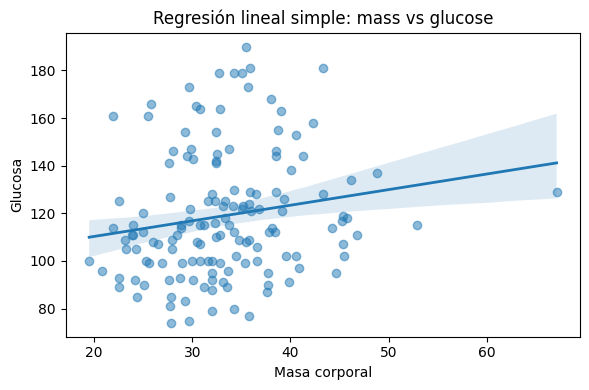

In [18]:
# Visualización de la regresión
plt.figure(figsize=(6,4))
sns.regplot(x=X_test['mass'], y=y_test, scatter_kws={'alpha':0.5}, line_kws={'linewidth':2})
plt.title('Regresión lineal simple: mass vs glucose')
plt.xlabel('Masa corporal')
plt.ylabel('Glucosa')
plt.tight_layout()
plt.show()

c:\Users\guill\Escritorio\INFORMATICA\data-science\data-science\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


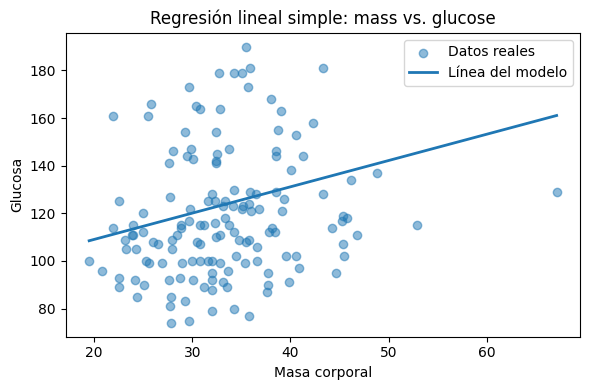

In [15]:
# 5) Visualizar (el modelo, no el ajuste interno de seaborn)
plt.figure(figsize=(6,4))
plt.scatter(X_test['mass'], y_test, alpha=0.5, label='Datos reales')
# Línea del modelo:
x_line = np.linspace(X_test['mass'].min(), X_test['mass'].max(), 100).reshape(-1,1)
y_line = lin_reg.predict(x_line)
plt.plot(x_line, y_line, linewidth=2, label='Línea del modelo')
plt.title('Regresión lineal simple: mass vs. glucose')
plt.xlabel('Masa corporal')
plt.ylabel('Glucosa')
plt.legend()
plt.tight_layout()
plt.show()

### Tabla de coeficientes

¿Qué significa cada elemento?

1. **Intercepto** (*intercept* o β₀)

   * Es el valor de la variable objetivo (`y`) cuando todas las variables independientes (`X`) valen cero.
   * Representa dónde “corta” la línea de regresión el eje `y`.

2. **Coeficientes** (*coef\_* o β₁, β₂, …)

   * Miden cuánto cambia la variable objetivo por **cada unidad adicional** de la variable correspondiente, manteniendo las demás constantes.
   * En tu ejemplo, `"mass"` tiene un coeficiente que indica:

     * Si es **positivo** → a mayor masa corporal, mayor valor esperado de glucosa.
     * Si es **negativo** → a mayor masa corporal, menor valor esperado de glucosa.

En modelos de **regresión simple** como el tuyo (solo `"mass"`), la ecuación quedaría:

$$
\hat{y} = \text{Intercepto} + (\text{coeficiente\_mass} \times \text{mass})
$$


In [19]:
# Tabla de coeficientes
coef_df = pd.DataFrame({
    "Parámetro": ["Intercepto", "mass"],
    "Estimación": [lin_reg.intercept_] + list(lin_reg.coef_)
})
display(coef_df)

,Parámetro,Estimación
0,Intercepto,86.951897
1,mass,1.104894


* **`lin_reg.intercept_`** → intercepto (β₀).
* **`lin_reg.coef_`** → coeficientes (β₁, β₂, …) asociados a cada variable predictora.
* El DataFrame `coef_df` organiza esta información de forma legible.

# 5. Regresión lineal múltiple

In [16]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro

# Cargar los datos de California Housing
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target, name='medv')

# Dividir en entrenamiento y prueba (80%-20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=46)

# Agregar una columna de unos para el término independiente
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)



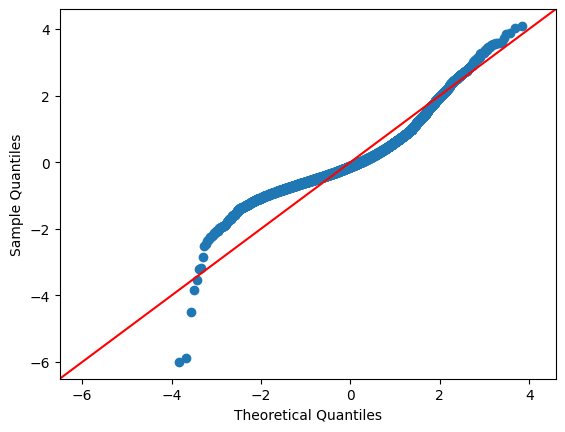

In [17]:
# Modelo de regresión lineal
model = sm.OLS(y_train, X_train).fit()

# Coeficientes
coefic_lm = model.summary2().tables[1]
coefic_lm = coefic_lm.round(4)

# Intervalos de confianza
conf_int = model.conf_int()

# Gráfico Q-Q
sm.qqplot(model.resid, line ='45')
plt.show()

In [18]:
# Residuos
residuals = model.resid

# Prueba de normalidad (Shapiro-Wilk)
stat, p_value = shapiro(residuals)
print(f'Shapiro-Wilk Test p-value: {p_value}')

Shapiro-Wilk Test p-value: 1.148012750917885e-67


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 16512.
  res = hypotest_fun_out(*samples, **kwds)


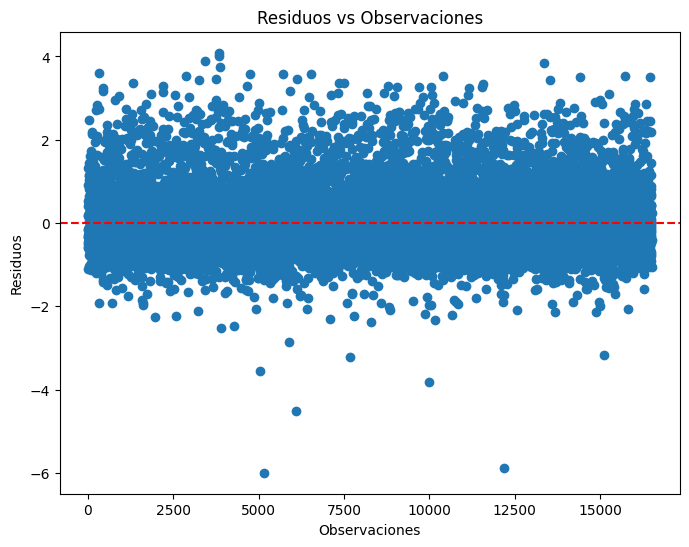

In [19]:
# Gráfico de residuos
plt.figure(figsize=(8, 6))
plt.scatter(np.arange(len(residuals)), residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Observaciones')
plt.ylabel('Residuos')
plt.title('Residuos vs Observaciones')
plt.show()

In [20]:
# Selección del mejor modelo (usando backward elimination)
from sklearn.feature_selection import RFE
lm = LinearRegression()
selector = RFE(lm, n_features_to_select=5)
selector = selector.fit(X_train.iloc[:, 1:], y_train)  # Excluyendo la constante
selected_features = X_train.columns[1:][selector.support_]

# Modelo con las mejores características
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]
model_selected = sm.OLS(y_train, sm.add_constant(X_train_selected)).fit()

In [21]:
# Predicciones y evaluación
def evaluate_predictions(obs, pred):
    e = obs - pred
    bias = np.mean(e)
    mse = np.mean(e**2)
    mae = np.mean(np.abs(e))
    rmse = np.sqrt(mse)
    R2 = 1 - (np.sum(e**2) / np.sum((obs - np.mean(obs))**2))
    return {'bias': bias, 'mse': mse, 'mae': mae, 'rmse': rmse, 'R2': R2}

# Predicción del modelo original
pred1 = model.predict(X_test)
metrics_mod1 = evaluate_predictions(y_test, pred1)

# Predicción del modelo con características seleccionadas
pred2 = model_selected.predict(sm.add_constant(X_test_selected))
metrics_mod2 = evaluate_predictions(y_test, pred2)

# Resultados
metrics_comparison = pd.DataFrame({
    'Model': ['Modelo 1', 'Modelo 2'],
    'Bias': [metrics_mod1['bias'], metrics_mod2['bias']],
    'MSE': [metrics_mod1['mse'], metrics_mod2['mse']],
    'MAE': [metrics_mod1['mae'], metrics_mod2['mae']],
    'RMSE': [metrics_mod1['rmse'], metrics_mod2['rmse']],
    'R2': [metrics_mod1['R2'], metrics_mod2['R2']]
})

print(metrics_comparison)

      Model      Bias       MSE       MAE      RMSE        R2
0  Modelo 1  0.007609  0.535014  0.538139  0.731447  0.602501
1  Modelo 2  0.011568  0.545974  0.540544  0.738901  0.594357


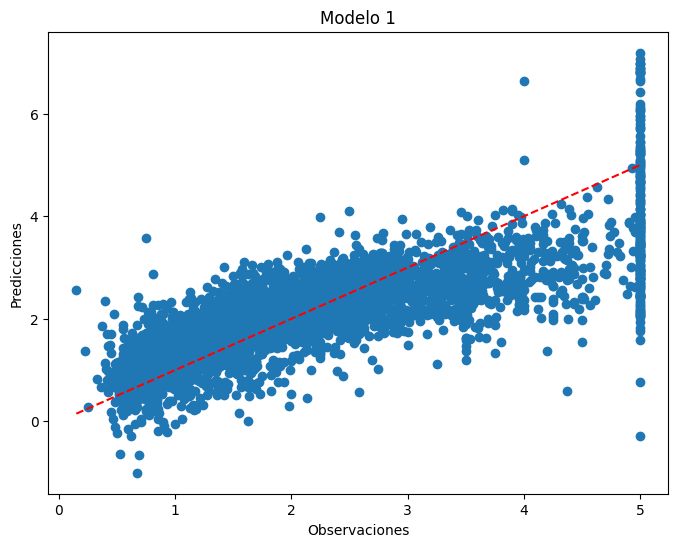

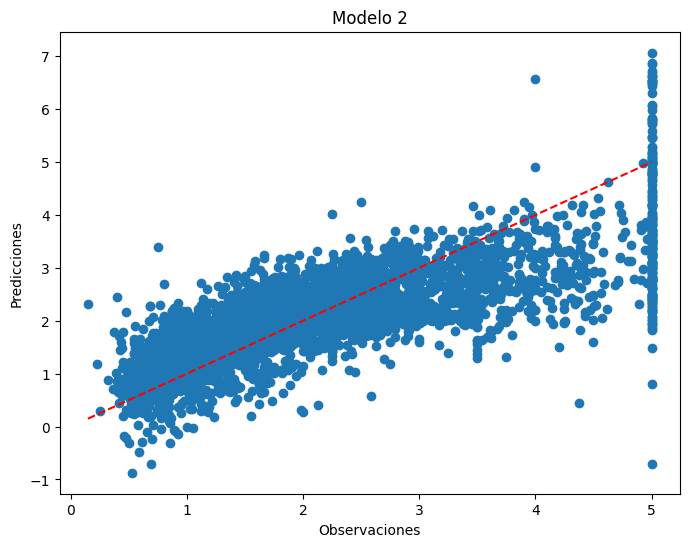

In [22]:
# Gráficos de predicción
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred1)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.xlabel('Observaciones')
plt.ylabel('Predicciones')
plt.title('Modelo 1')
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred2)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red')
plt.xlabel('Observaciones')
plt.ylabel('Predicciones')
plt.title('Modelo 2')
plt.show()